## Find the farthest point inside a 2D polygon

Input = polygon (may have holes) + start point
Output = farthest point, shortest path to start point & distance

In [1]:
# ───────────────────────────────────────────────────────────────────
#  Farthest vertex inside a (possibly‑holed) polygon
#  – shortest path that never leaves the polygon
#  – simple, self‑contained, uses only Shapely & matplotlib
# ───────────────────────────────────────────────────────────────────
from shapely.geometry import Polygon, Point, LineString
import random
import heapq
import matplotlib.pyplot as plt

def sample_point_in_polygon(poly, attempts=2000):
    minx, miny, maxx, maxy = poly.bounds
    for _ in range(attempts):
        px = random.uniform(minx, maxx)
        py = random.uniform(miny, maxy)
        p = Point(px, py)
        if poly.contains(p):
            return p
    raise RuntimeError("Failed to sample point inside polygon (not in holes)")

def build_visibility_graph(poly: Polygon, start: Point, goal: Point = None):
    """
    Build a visibility graph for the given polygon and start point.
    Returns (nodes, adjacency_dict).

    - poly  : Shapely Polygon (may have holes)
    - start : Point inside the polygon
    - goal  : Optional Point (if specified, will be added to the graph)
    """
    # 1. Collect all vertices (exterior + interiors)
    # Exterior vertices
    nodes = [Point(c) for c in poly.exterior.coords]
    # Interior vertices (one per hole)
    for ring in poly.interiors:
        nodes.extend(Point(c) for c in ring.coords)
    # Insert start point at index 0
    nodes.insert(0, start)
    # Optional: insert goal point (if specified)
    if goal is not None:
        nodes.insert(1, goal)
    n_nodes = len(nodes)

    # 2. Build adjacency list (visibility)
    adj = {i: [] for i in range(n_nodes)}
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            seg = LineString([nodes[i], nodes[j]])
            # `covers` is True only if the segment lies entirely
            # inside the polygon (or on its boundary), which automatically
            # forbids crossing a hole.
            if poly.covers(seg):  # valid line of sight
                d = seg.length
                adj[i].append((j, d))
                adj[j].append((i, d))

    return nodes, adj

def dijkstra_shortest_paths(adj, start_idx, goal_idx=None):
    """
    Compute shortest paths using Dijkstra's algorithm.
    Returns (distances, predecessors).

    - adj        : adjacency dict {node: [(neighbor, weight), ...]}
    - start_idx  : index of the start node
    - goal_idx   : optional index of a specific goal node for early exit
    """
    n_nodes = len(adj)
    dist = [float('inf')] * n_nodes
    pred = [None] * n_nodes
    dist[start_idx] = 0.0
    pq = [(0.0, start_idx)] # (distance, node index)

    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        # Optional early exit if we have a specific goal
        if u == goal_idx: break
        for v, w in adj[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                pred[v] = u
                heapq.heappush(pq, (nd, v))

    return dist, pred

def farthest_vertex_and_path(poly: Polygon, start: Point):
    """
    Return (farthest_point, distance, path_points)
    """
    nodes, adj = build_visibility_graph(poly, start)
    dist, pred = dijkstra_shortest_paths(adj, 0)

    # Find farthest reachable node
    farthest_idx = max(range(1, len(nodes)), key=lambda i: dist[i])

    # Reconstruct path
    path = []
    cur = farthest_idx
    while cur is not None:
        path.append(nodes[cur])
        cur = pred[cur]
    path.reverse()

    return nodes[farthest_idx], dist[farthest_idx], path

def shortest_vertex_and_path(poly: Polygon, start: Point, goal: Point):
    """
    Return (shortest_point, distance, path_points)
    """
    nodes, adj = build_visibility_graph(poly, start, goal)
    dist, pred = dijkstra_shortest_paths(adj, 0, 1)

    # Find farthest reachable node
    # farthest_idx = max(range(1, len(nodes)), key=lambda i: dist[i])

    # Reconstruct path
    path = []
    cur = 1  # index of the goal node
    while cur is not None:
        path.append(nodes[cur])
        cur = pred[cur]
    path.reverse()

    return nodes[1], dist[1], path

Farthest point: POINT (30 0)
Geodesic distance: 33.0927 meters


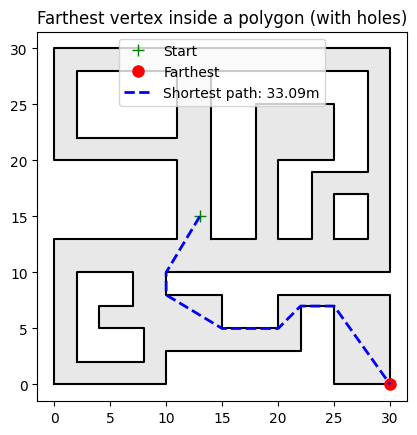

In [5]:
# ───────────────────────────────────────────────────────────────────
#  Demo: polygon with a hole
# ───────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    demo = 4

    if demo == 1:
        # Demo 1
        # A square with a rectangular hole inside
        outer = [(0, 0), (10, 0), (10, 10), (0, 10)]
        hole  = [(3, 3), (7, 3), (7, 7), (3, 7)]
        poly   = Polygon(outer, [hole])

    # Demo 2
    if demo == 2:
        outer = [(0,0), (10, 0), (10, 10), (30, 10), (30, 30), (0, 30)]
        hole1  = [(3, 3), (7, 3), (7, 7), (3, 7)]
        hole2 = [
                (5, 21),
                (5, 28),
                (11, 28),
                (11, 21)
            ]
        hole3 =     [
                (14, 13),
                (14, 28),
                (28, 28),
                (28, 19),
                (23, 19),
                (23, 13)
            ]
        poly   = Polygon(outer, [hole1, hole2, hole3])

    # Demo 3
    if demo == 3:
        outer = [
            (0,0), (10, 0),
            (10, 3), (25, 3), (25, 8), (20, 8), (20, 5), (15,5), (15,8), (10, 8),
            (10, 10), (30, 10), (30, 30), (0, 30),
            (0,20), (11,20), (11,13),(0,13)
        ]
        # offset outer to the inside by 1m (for better visualization of paths near the boundary)
        # outer = LineString(outer).parallel_offset(1, 'left', join_style=2).coords
        # clockwise numbering!
        holes = [
            [(2, 3), (7, 3), (7, 10), (2, 10)],
            [(25, 13), (28, 13), (28, 17), (25, 17)],
            [(2, 22), (2, 28), (11, 28), (11, 22)],
            [(14, 13), (14, 28), (28, 28), (28, 19), (23, 19), (23, 13),
             (20, 13), (20, 20), (25, 20), (25, 25), (18, 25), (18, 13)]
        ]
        # outer = LineString(outer).parallel_offset(0.5, 'left', join_style=2).coords

        poly = Polygon(outer, holes=holes)

    # Demo 4
    if demo == 4:
        outer = [
            (0,0), (10, 0),
            (10, 3), (22,3), (22,7), (25,7),(25, 3), (25,0), (30,0),(30, 3), (30, 8), (20, 8), (20, 5), (15,5), (15,8), (10, 8),
            (10, 10), (30, 10), (30, 30), (0, 30),
            (0,20), (11,20), (11,13),(0,13)
        ]
        # offset outer to the inside by 1m (for better visualization of paths near the boundary)
        # outer = LineString(outer).parallel_offset(1, 'left', join_style=2).coords
        # clockwise numbering!
        holes = [
            [(2, 2), (8, 2), (8,5), (4,5), (4,7), (7,7), (7, 10), (2, 10)],
            [(25, 13), (28, 13), (28, 17), (25, 17)],
            [(2, 22), (2, 28), (11, 28), (11, 22)],
            [(14, 13), (14, 28), (28, 28), (28, 19), (23, 19), (23, 13),
             (20, 13), (20, 20), (25, 20), (25, 25), (18, 25), (18, 13)]
        ]
        # outer = LineString(outer).parallel_offset(0.5, 'left', join_style=2).coords

        poly = Polygon(outer, holes=holes)

    single = True
    should_find_shortest = False
    if (single):
        start  = Point(27, 11)
        start  = Point(13, 15)
        # start  = Point(5, 6)
        # start = sample_point_in_polygon(poly)   # random point in exterior (not in holes)
        if should_find_shortest:
            goal = sample_point_in_polygon(poly)   # random point in exterior (not in holes)
            shortest, d, path = shortest_vertex_and_path(poly, start, goal)
            print(f"Shortest path to {goal}: {d:.4f} meters")
        else:
            farthest, d, path = farthest_vertex_and_path(poly, start)
            print(f"Farthest point: {farthest}")
            print(f"Geodesic distance: {d:.4f} meters")
    else:
        # Stress testing with multiple random starts
        paths = []
        for _ in range(8):
            start = sample_point_in_polygon(poly)   # random point in exterior (not in holes)
            farthest, d, path = farthest_vertex_and_path(poly, start)
            print(f"Start: {start}, Farthest: {farthest}, Distance: {d:.4f}")
            paths.append(path)

    plotting = True
    if plotting:
            # ── Plot ---------------------------------------
            fig, ax = plt.subplots()
            # Outer ring
            x, y = poly.exterior.xy
            ax.plot(x, y, 'k-', lw=1.5)
            ax.fill(x, y, 'lightgray', alpha=0.5)
            # Hole(s)
            for interior in poly.interiors:
                hx, hy = interior.xy
                ax.plot(hx, hy, 'k-', lw=1.5)
                # filled hole (for better visibility)
                ax.fill(hx, hy, 'white', alpha=1)
            # Start / farthest
            ax.plot(start.x, start.y, 'g+', ms=8, label='Start')
            if should_find_shortest:
                ax.plot(goal.x, goal.y, 'rx', ms=8, label='Goal')
            else:
                ax.plot(farthest.x, farthest.y, 'ro', ms=8, label='Farthest')
            
            if (single):
                # Path
                px = [p.x for p in path]
                py = [p.y for p in path]
                ax.plot(px, py, 'b--', lw=2, label=f'Shortest path: {d:.2f}m')
            else:
                for path in paths:
                    ax.plot(path[0].x, path[0].y, 'go', ms=8, label='Start')
                    ax.plot(path[-1].x, path[-1].y, 'ro', ms=8, label='Farthest')
                    px = [p.x for p in path]
                    py = [p.y for p in path]
                    ax.plot(px, py, 'b--', lw=2)
            ax.set_aspect('equal')
            if should_find_shortest:
                ax.set_title('Shortest path between two points\ninside a polygon (with holes)')
            else:
                ax.set_title('Farthest vertex inside a polygon (with holes)')
            ax.legend()
            plt.show()
